In [ ]:
# ==========================================
# INSTALL
# ==========================================
!pip install -q transformers sentencepiece accelerate faiss-cpu \
sentence-transformers evaluate sacrebleu rouge-score matplotlib tqdm scikit-learn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.0 MB/s eta 0:00:00


In [ ]:
# ==========================================
# IMPORTS
# ==========================================
import os
import gc
import json
import faiss
import torch
import evaluate
import sacrebleu
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer, util

from transformers import (
    MBartForConditionalGeneration,
    MBart50TokenizerFast
)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ==========================================
# PATHS
# ==========================================
BASE_DIR = "/content/drive/MyDrive/MALAYALAM_RAG_PROJECT/mbart_rag"

os.makedirs(BASE_DIR, exist_ok=True)

PRED_PATH = f"{BASE_DIR}/predictions.csv"
RESULTS_PATH = f"{BASE_DIR}/full_results.csv"
SUMMARY_PATH = f"{BASE_DIR}/summary_metrics.json"

In [ ]:
# ==========================================
# LOAD DATA
# ==========================================
train_df = pd.read_csv("/content/drive/MyDrive/train.csv")
valid_df = pd.read_csv("/content/drive/MyDrive/validation.csv")

train_df = train_df[["article", "summary"]].dropna()
valid_df = valid_df[["article", "summary"]].dropna()

print(train_df.shape)
print(valid_df.shape)

(7758, 2)
(970, 2)


In [ ]:
# ==========================================
# CHUNKING
# ==========================================
def chunk_text(text, chunk_size=1000, overlap=150):
    chunks = []
    start = 0

    while start < len(text):
        end = start + chunk_size
        chunks.append(text[start:end])
        start += chunk_size - overlap

    return chunks

In [ ]:
# ==========================================
# BUILD CORPUS
# ==========================================
all_chunks = []

for article in tqdm(train_df["article"]):
    article = str(article)
    chunks = chunk_text(article)
    all_chunks.extend(chunks)

chunk_df = pd.DataFrame({"chunk": all_chunks})

print("Total chunks:", len(chunk_df))

100%|██████████| 7758/7758 [00:00<00:00, 778939.30it/s]

Total chunks: 7809


In [ ]:
# ==========================================
# EMBEDDING MODEL
# ==========================================
embedding_model = SentenceTransformer(
    "intfloat/multilingual-e5-base",
    device="cuda" if torch.cuda.is_available() else "cpu"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

In [ ]:
# ==========================================
# EMBEDDINGS
# ==========================================
BATCH_SIZE = 64
all_embeddings = []

chunk_texts = chunk_df["chunk"].tolist()

for i in tqdm(range(0, len(chunk_texts), BATCH_SIZE)):
    batch = chunk_texts[i:i+BATCH_SIZE]

    emb = embedding_model.encode(
        batch,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False
    )

    all_embeddings.append(emb)

embeddings = np.vstack(all_embeddings)

print(embeddings.shape)

100%|██████████| 123/123 [00:54<00:00,  2.26it/s]

(7809, 768)


In [ ]:
# ==========================================
# FAISS INDEX
# ==========================================
dimension = embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)
index.add(embeddings)

print("FAISS ready")

FAISS ready


In [ ]:
# ==========================================
# RETRIEVAL
# ==========================================
def retrieve_context(query, top_k=2):
    q_emb = embedding_model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    scores, indices = index.search(q_emb, top_k)

    contexts = [
        chunk_df.iloc[idx]["chunk"]
        for idx in indices[0]
    ]

    return contexts

In [ ]:
# ==========================================
# TEST RETRIEVAL
# ==========================================
sample_article = valid_df.iloc[0]["article"]

contexts = retrieve_context(sample_article)

for i, ctx in enumerate(contexts):
    print(f"\nContext {i+1}")
    print(ctx[:500])


Context 1
കണ്ണൂർ: തുടർച്ചയായി എത്തുന്ന മഴയും മണ്ണിടിച്ചിലും കാരണം കണ്ണൂർ വിമാനത്താവളത്തിന് പരിസരത്ത് താമസിക്കുന്ന കുടുംബങ്ങൾ ഭീഷണിയിലായിരിക്കുകയാണ്.

Context 2
കൽപറ്റ: മഴക്കെടുതിയിൽ വീട് നഷ്ടപ്പെട്ട് ആട്ടിൻ കൂട്ടിൽ അഭയം തേടിയിരിക്കുകയാണ് വയനാട് നടവയലിലെ ഒരുകുടുംബം.


In [ ]:
# ==========================================
# LOAD PRETRAINED MBART
# ==========================================
MODEL_NAME = "facebook/mbart-large-50-many-to-many-mmt"

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = MBart50TokenizerFast.from_pretrained(
    MODEL_NAME,
    src_lang="ml_IN",
    tgt_lang="ml_IN"
)

model = MBartForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
).to(device)

model.eval()

tokenizer_config.json:   0%|          | 0.00/529 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/649 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/2.44G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/261 [00:00<?, ?B/s]

MBartForConditionalGeneration(
  (model): MBartModel(
    (shared): MBartScaledWordEmbedding(250054, 1024, padding_idx=1)
    (encoder): MBartEncoder(
      (embed_tokens): MBartScaledWordEmbedding(250054, 1024, padding_idx=1)
      (embed_positions): MBartLearnedPositionalEmbedding(1026, 1024)
      (layers): ModuleList(
        (0-11): 12 x MBartEncoderLayer(
          (self_attn): MBartAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (activation_fn): ReLU()
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (fc2): Linear(in_features=4096, out_features=1024, bias=True)
        

In [ ]:
# ==========================================
# PROMPT
# ==========================================
def build_prompt(article, contexts):
    context_text = "\n".join(contexts)

    return f"""
പശ്ചാത്തല വിവരം:
{context_text}

ലേഖനം:
{article}

മലയാളത്തിൽ ചുരുക്കമായ സംഗ്രഹം:
"""

In [ ]:
# ==========================================
# GENERATION FUNCTION
# ==========================================
def generate_summary(article):
    article = str(article)

    contexts = retrieve_context(article, top_k=2)

    prompt = build_prompt(article, contexts)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024
    ).to(device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            forced_bos_token_id=tokenizer.lang_code_to_id["ml_IN"],
            max_new_tokens=80,
            num_beams=4,
            do_sample=False,
            repetition_penalty=1.8,
            no_repeat_ngram_size=3,
            early_stopping=True
        )

    pred = tokenizer.decode(
        output[0],
        skip_special_tokens=True
    )

    pred = pred.replace(prompt, "").strip()

    return pred, contexts

In [ ]:
# ==========================================
# FULL PREDICTION LOOP
# ==========================================
articles = []
references = []
predictions = []
retrieved_1 = []
retrieved_2 = []

RUN_ROWS = len(valid_df)   # full validation

# for testing:
# RUN_ROWS = 50

subset = valid_df.iloc[:RUN_ROWS]

In [ ]:
# ==========================================
# GENERATE
# ==========================================
for _, row in tqdm(subset.iterrows(), total=len(subset)):
    article = str(row["article"])
    reference = str(row["summary"])

    try:
        pred, contexts = generate_summary(article)

        ctx1 = contexts[0] if len(contexts) > 0 else ""
        ctx2 = contexts[1] if len(contexts) > 1 else ""

    except Exception as e:
        print("Error:", e)

        pred = ""
        ctx1 = ""
        ctx2 = ""

    articles.append(article)
    references.append(reference)
    predictions.append(pred)
    retrieved_1.append(ctx1)
    retrieved_2.append(ctx2)

    torch.cuda.empty_cache()

100%|██████████| 970/970 [10:00<00:00,  1.62it/s]


In [ ]:
# ==========================================
# SAVE PREDICTIONS
# ==========================================
pred_df = pd.DataFrame({
    "article": articles,
    "reference": references,
    "retrieved_context_1": retrieved_1,
    "retrieved_context_2": retrieved_2,
    "prediction": predictions
})

pred_df.to_csv(
    PRED_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", PRED_PATH)

Saved: /content/drive/MyDrive/MALAYALAM_RAG_PROJECT/mbart_rag/predictions.csv


In [ ]:
# ==========================================
# SAMPLE CHECK
# ==========================================
display(pred_df.sample(5))

,article,reference,retrieved_context_1,retrieved_context_2,prediction
440,പരശുപുരം ഗ്രാമത്തിൽ പൊങ്ങച്ചക്കാരൻ പോക്കർ എന്ന...,പുഴ.കോം - നവസംസ്കൃതിയുടെ ജലസമൃദ്ധി,കുറുക്കന്തറയിൽ കൗശലൻ എന്നു പേരുളള ഒരു കുറുക്കന...,ഒരു ഗ്രാമത്തിൽ മണിയൻ എന്നൊരു തൊഴിലാളി താമസിച്ച...,കുറുക്കത്തിൽ കൗശൻ എന്ന പേരുള്ള ഒരുകുറുക്കൻ.
525,ന്യൂഡൽഹി: ജമ്മു കശ്മീരിൽ സ്ഥിതിഗതികൾ അശാന്തമെന...,ജമ്മു കശ്മീരിൽ സ്ഥിതിഗതികൾ അശാന്തമെന്ന് വ്യക്ത...,ദില്ലി: കശ്മീരി ലെ സ്ഥിതിഗതികള് ഗുരുതരമാണെന്ന്...,ന്യൂഡല്ഹി: ജമ്മുകശ്മീരില് അക്രമസംഭവങ്ങള് റിപ്പ...,ജര് മ്മനി ഗവര് ണര് സത്യപാല് സിങ്ങിന് റെ അഭിപ്ര...
421,"ഡല്ഹി: കശ്മീരിലെ ജനങ്ങള്ക്ക് ജയിലുകളല്ല, തൊഴില...","കാശ്മീരിലെ ജനങ്ങള്ക്ക് ജയിലുകളല്ല, തൊഴിലാണ് വേ...",ദില്ലി: കശ്മീരി ലെ സ്ഥിതിഗതികള് ഗുരുതരമാണെന്ന്...,ന്യൂഡല്ഹി: കശ്മീര് ഭരണഘടന ഭേദഗതിയുമായി ബന്ധപ്പ...,The situation in Kashmir is serious.
561,തിരുവനന്തപുരം: പൊലീസ് സര്വ്വീസ് സഹകരണ സംഘം തെര...,അസോസിയേഷനിലെ തമ്മിൽത്തല്ല്: 8 പൊലീസുകാർക്ക് സസ...,തിരുവനന്തപുരം : എക്സൈസ് കസ്റ്റഡിയിൽ കഞ്ചാവ് കേ...,തിരുവനന്തപുരം: കാട്ടാക്കട കൊലപാതകവുമായി ബന്ധപ്...,സർവ്വീസ് കമ്മ്യൂണിറ്റി 8 പോലീസുകാരെ suspended ...
119,"ജയരാജൻ 5, 2018 തിരുവനന്തപുരം: പ്രളയക്കെടുതിയേത...",പി.കെ.ശശിക്കെതിരായ ലൈംഗികാരോപണ വിഷയം പാർട്ടിക്...,വി ആയി 'കില'യെ സർക്കാർ ചുമതലപ്പെടുത്തുകയും ചെയ...,തിരുവനന്തപുരം: സംസ്ഥാനത്ത് മൂന്നു നോവൽ കൊറോണ വ...,സർക്യൂട്ട്[Education]Minister C. Ravindranath ...


In [ ]:
# ==========================================
# CLEANUP BEFORE METRICS
# ==========================================
gc.collect()
torch.cuda.empty_cache()

In [ ]:
# ==========================================
# LOAD PRED CSV
# ==========================================
pred_df = pd.read_csv(PRED_PATH)

pred_df = pred_df.fillna("")

articles = pred_df["article"].astype(str).tolist()
references = pred_df["reference"].astype(str).tolist()
predictions = pred_df["prediction"].astype(str).tolist()
retrieved1 = pred_df["retrieved_context_1"].astype(str).tolist()
retrieved2 = pred_df["retrieved_context_2"].astype(str).tolist()

retrieved_contexts = [
    r1 + " " + r2
    for r1, r2 in zip(retrieved1, retrieved2)
]

In [ ]:
# ==========================================
# BASIC METRICS
# ==========================================
rouge = evaluate.load("rouge")

rouge_scores = rouge.compute(
    predictions=predictions,
    references=references
)

bleu = sacrebleu.corpus_bleu(
    predictions,
    [references]
).score

In [ ]:
# ==========================================
# SEMANTIC SIMILARITY
# ==========================================
pred_emb = embedding_model.encode(
    predictions,
    batch_size=16,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

ref_emb = embedding_model.encode(
    references,
    batch_size=16,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

bert_per_sample = np.sum(pred_emb * ref_emb, axis=1)

bertscore = bert_per_sample.mean()

Batches:   0%|          | 0/61 [00:00<?, ?it/s]

Batches:   0%|          | 0/61 [00:00<?, ?it/s]

In [ ]:
# ==========================================
# FAITHFULNESS
# ==========================================
ctx_emb = embedding_model.encode(
    retrieved_contexts,
    batch_size=16,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

faithfulness_scores = np.sum(pred_emb * ctx_emb, axis=1)

faithfulness = faithfulness_scores.mean()

Batches:   0%|          | 0/61 [00:00<?, ?it/s]

In [ ]:
# ==========================================
# CONTEXT PRECISION
# ==========================================
cp_scores = []

for pred, ctx in tqdm(zip(predictions, retrieved_contexts), total=len(predictions)):
    pred_sentences = pred.split(".")

    if len(pred_sentences) == 0:
        cp_scores.append(0)
        continue

    ctx_emb_local = embedding_model.encode(
        ctx,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    supported = 0
    valid_sent = 0

    for sent in pred_sentences:
        sent = sent.strip()

        if len(sent) < 5:
            continue

        valid_sent += 1

        sent_emb = embedding_model.encode(
            sent,
            convert_to_numpy=True,
            normalize_embeddings=True
        )

        sim = np.dot(sent_emb, ctx_emb_local)

        if sim > 0.65:
            supported += 1

    cp = supported / max(valid_sent, 1)
    cp_scores.append(cp)

cp_scores = np.array(cp_scores)
context_precision = cp_scores.mean()

100%|██████████| 970/970 [00:29<00:00, 32.95it/s]


In [ ]:
# ==========================================
# CONTEXT RECALL
# ==========================================
cr_scores = []

for pred, ctx in tqdm(zip(predictions, retrieved_contexts), total=len(predictions)):
    ctx_chunks = [c for c in ctx.split("\n") if len(c.strip()) > 20]

    pred_emb_local = embedding_model.encode(
        pred,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    covered = 0

    for chunk in ctx_chunks:
        chunk_emb = embedding_model.encode(
            chunk,
            convert_to_numpy=True,
            normalize_embeddings=True
        )

        sim = np.dot(pred_emb_local, chunk_emb)

        if sim > 0.65:
            covered += 1

    cr = covered / max(len(ctx_chunks), 1)
    cr_scores.append(cr)

cr_scores = np.array(cr_scores)
context_recall = cr_scores.mean()

100%|██████████| 970/970 [00:30<00:00, 31.34it/s]


In [ ]:
# ==========================================
# HALLUCINATION SCORE
# ==========================================
hallucination_scores = 1 - (
    0.4 * faithfulness_scores +
    0.2 * cp_scores +
    0.2 * cr_scores +
    0.2 * bert_per_sample
)

hallucination_rate = (hallucination_scores > 0.5).mean()

In [ ]:
# ==========================================
# SUMMARY METRICS
# ==========================================
summary_metrics = {
    "rouge1": float(rouge_scores["rouge1"]),
    "rouge2": float(rouge_scores["rouge2"]),
    "rougeL": float(rouge_scores["rougeL"]),
    "bleu": float(bleu),
    "bertscore": float(bertscore),

    "faithfulness": float(faithfulness),
    "context_precision": float(context_precision),
    "context_recall": float(context_recall),

    "hallucination_score": float(hallucination_scores.mean()),
    "hallucination_rate": float(hallucination_rate)
}

print(summary_metrics)

{'rouge1': 0.006734502875617106, 'rouge2': 0.0, 'rougeL': 0.006655515479658758, 'bleu': 0.16443164090688803, 'bertscore': 0.7900398373603821, 'faithfulness': 0.8228835463523865, 'context_precision': 0.6989690721649484, 'context_recall': 1.0, 'hallucination_score': 0.17304481380993567, 'hallucination_rate': 0.0}


In [ ]:
# ==========================================
# SAVE FULL RESULTS
# ==========================================
full_df = pd.DataFrame({
    "article": articles,
    "reference": references,
    "prediction": predictions,

    "bertscore": bert_per_sample,
    "faithfulness": faithfulness_scores,
    "context_precision": cp_scores,
    "context_recall": cr_scores,
    "hallucination_score": hallucination_scores
})

full_df.to_csv(
    RESULTS_PATH,
    index=False,
    encoding="utf-8-sig"
)

In [ ]:
# ==========================================
# SAVE JSON
# ==========================================
with open(SUMMARY_PATH, "w") as f:
    json.dump(summary_metrics, f, indent=4)

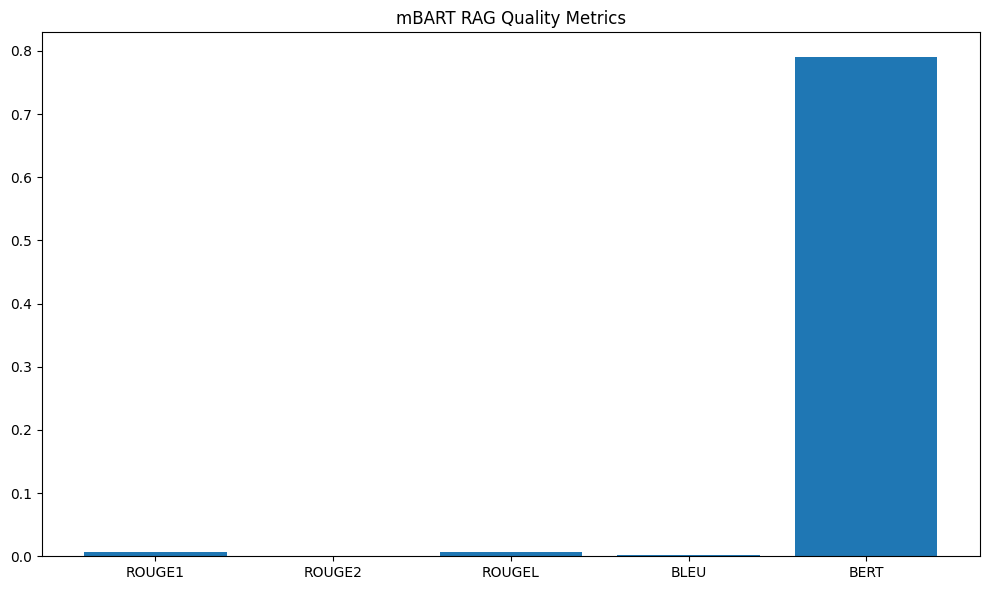

In [ ]:
# ==========================================
# QUALITY PLOT
# ==========================================
plt.figure(figsize=(10,6))

quality_names = ["ROUGE1","ROUGE2","ROUGEL","BLEU","BERT"]
quality_vals = [
    summary_metrics["rouge1"],
    summary_metrics["rouge2"],
    summary_metrics["rougeL"],
    summary_metrics["bleu"]/100,
    summary_metrics["bertscore"]
]

plt.bar(quality_names, quality_vals)
plt.title("mBART RAG Quality Metrics")
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/quality_metrics.png")
plt.show()

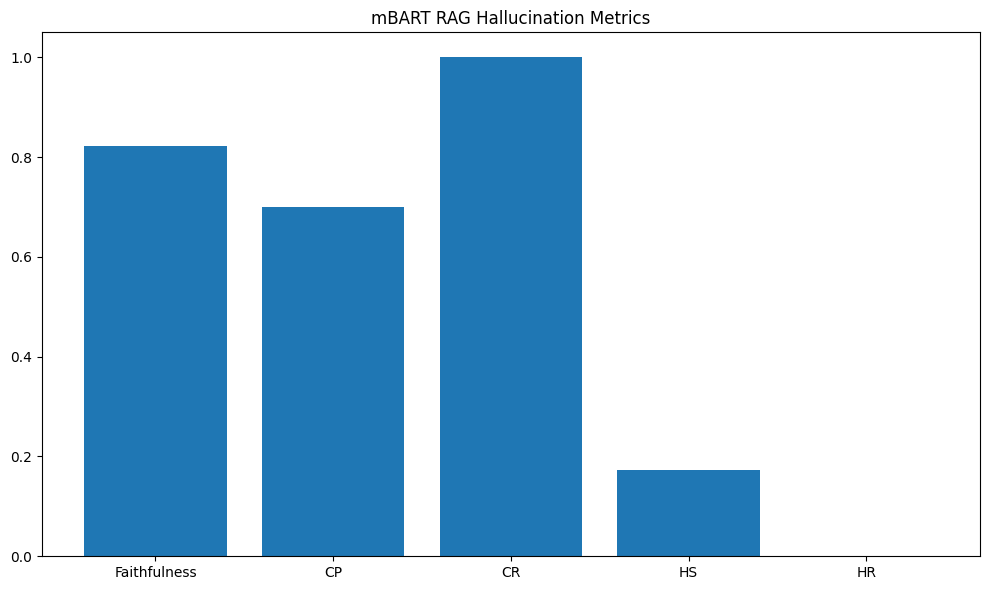

In [ ]:
# ==========================================
# HALLUCINATION PLOT
# ==========================================
plt.figure(figsize=(10,6))

hall_names = ["Faithfulness","CP","CR","HS","HR"]
hall_vals = [
    summary_metrics["faithfulness"],
    summary_metrics["context_precision"],
    summary_metrics["context_recall"],
    summary_metrics["hallucination_score"],
    summary_metrics["hallucination_rate"]
]

plt.bar(hall_names, hall_vals)
plt.title("mBART RAG Hallucination Metrics")
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/hallucination_metrics.png")
plt.show()

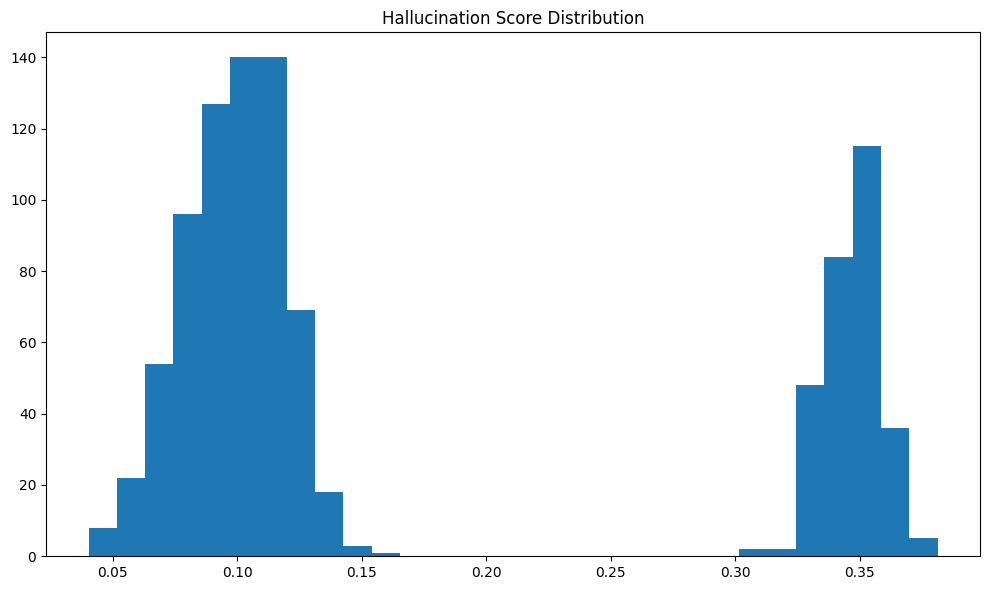

In [ ]:
# ==========================================
# DISTRIBUTION
# ==========================================
plt.figure(figsize=(10,6))
plt.hist(hallucination_scores, bins=30)
plt.title("Hallucination Score Distribution")
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/hallucination_distribution.png")
plt.show()

In [ ]:
del model
del tokenizer
gc.collect()
torch.cuda.empty_cache()

In [ ]:
BASE_DIR = "/content/drive/MyDrive/MALAYALAM_RAG_PROJECT/mt5_rag"

os.makedirs(BASE_DIR, exist_ok=True)

PRED_PATH = f"{BASE_DIR}/predictions.csv"
RESULTS_PATH = f"{BASE_DIR}/full_results.csv"
SUMMARY_PATH = f"{BASE_DIR}/summary_metrics.json"

In [ ]:
from transformers import AutoTokenizer, MT5ForConditionalGeneration
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

MODEL_NAME = "google/mt5-base"

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = MT5ForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
).to(device)

model.eval()

print("mT5 loaded")

Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


mT5 loaded


In [ ]:
def build_prompt(article, contexts):
    context_text = "\n".join(contexts)

    return f"""
പശ്ചാത്തല വിവരം:
{context_text}

ലേഖനം:
{article}

നിർദേശം:
മലയാളത്തിൽ ചുരുക്കമായ വാർത്താ സംഗ്രഹം മാത്രം നൽകുക.

സംഗ്രഹം:
"""

In [ ]:
def generate_summary(article):
    article = str(article)

    contexts = retrieve_context(article, top_k=2)

    prompt = build_prompt(article, contexts)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024
    ).to(device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=80,
            num_beams=4,
            do_sample=False,
            repetition_penalty=1.8,
            no_repeat_ngram_size=3,
            early_stopping=True
        )

    pred = tokenizer.decode(
        output[0],
        skip_special_tokens=True
    )

    pred = pred.replace(prompt, "").strip()

    return pred, contexts

In [ ]:
articles = []
references = []
predictions = []
retrieved_1 = []
retrieved_2 = []

RUN_ROWS = len(valid_df)

subset = valid_df.iloc[:RUN_ROWS]

for _, row in tqdm(subset.iterrows(), total=len(subset)):
    article = str(row["article"])
    reference = str(row["summary"])

    try:
        pred, contexts = generate_summary(article)

        ctx1 = contexts[0] if len(contexts) > 0 else ""
        ctx2 = contexts[1] if len(contexts) > 1 else ""

    except Exception as e:
        print("Error:", e)

        pred = ""
        ctx1 = ""
        ctx2 = ""

    articles.append(article)
    references.append(reference)
    predictions.append(pred)
    retrieved_1.append(ctx1)
    retrieved_2.append(ctx2)

    torch.cuda.empty_cache()

100%|██████████| 970/970 [06:18<00:00,  2.56it/s]


In [ ]:
pred_df = pd.DataFrame({
    "article": articles,
    "reference": references,
    "retrieved_context_1": retrieved_1,
    "retrieved_context_2": retrieved_2,
    "prediction": predictions
})

pred_df.to_csv(
    PRED_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", PRED_PATH)

Saved: /content/drive/MyDrive/MALAYALAM_RAG_PROJECT/mt5_rag/predictions.csv


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/61 [00:00<?, ?it/s]

Batches:   0%|          | 0/61 [00:00<?, ?it/s]

Batches:   0%|          | 0/61 [00:00<?, ?it/s]

100%|██████████| 970/970 [06:56<00:00,  2.33it/s]


{'rouge1': 0.0010505645557191948, 'rouge2': 0.0, 'rougeL': 0.0010014727540500737, 'bleu': 0.37259275585198626, 'bertscore': 0.7824975252151489, 'faithfulness': 0.7870193719863892, 'context_precision': 1.0, 'context_recall': 1.0, 'hallucination_score': 0.12869271975509908, 'hallucination_rate': 0.0}


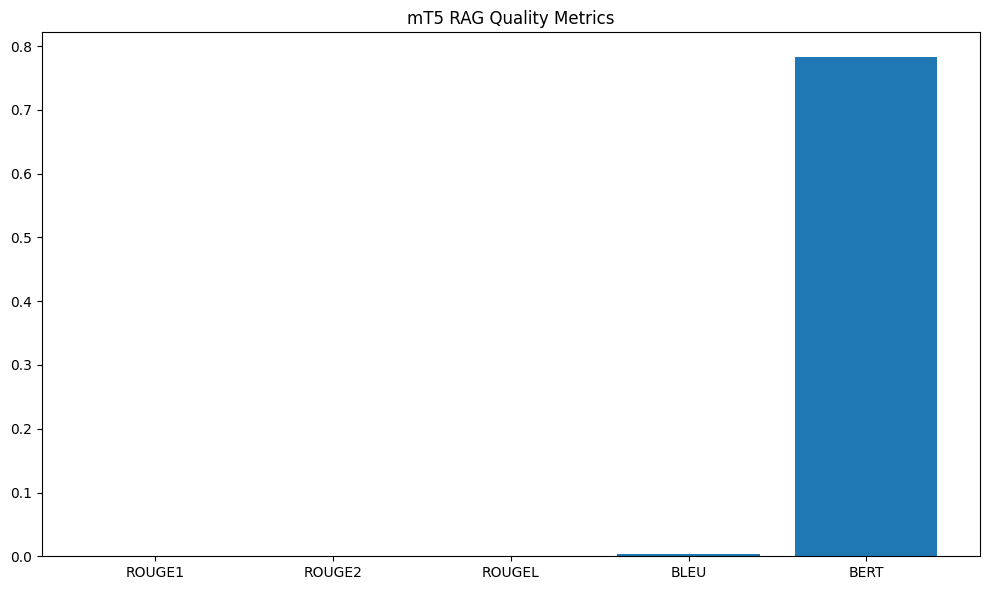

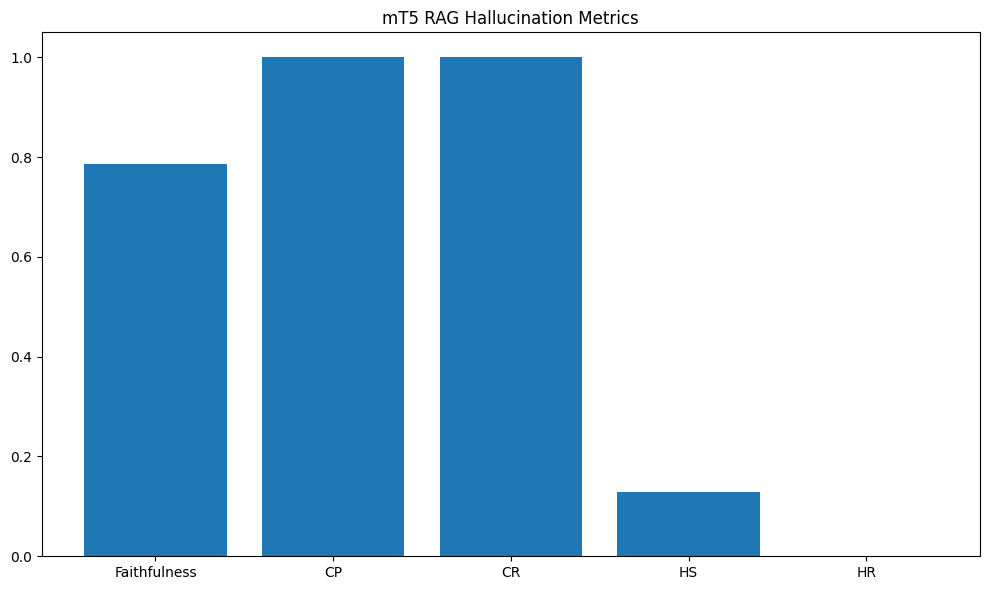

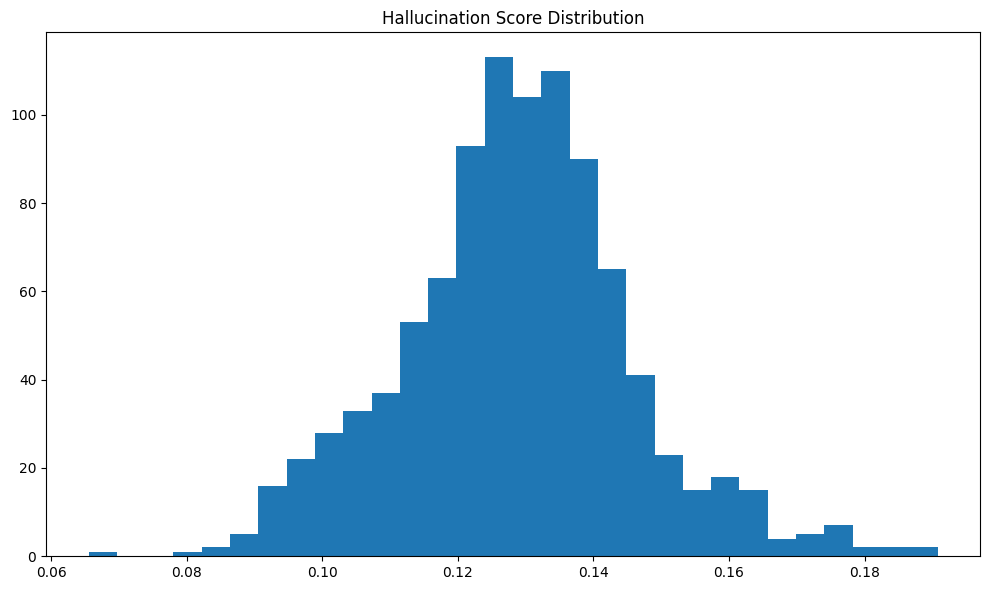

DONE


In [ ]:
import os
import gc
import json
import torch
import evaluate
import sacrebleu
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from sentence_transformers import SentenceTransformer

# ==========================================
# PATHS
# ==========================================
BASE_DIR = "/content/drive/MyDrive/MALAYALAM_RAG_PROJECT/mt5_rag"

PRED_PATH = f"{BASE_DIR}/predictions.csv"
RESULTS_PATH = f"{BASE_DIR}/full_results.csv"
SUMMARY_PATH = f"{BASE_DIR}/summary_metrics.json"

# ==========================================
# LOAD PREDICTIONS
# ==========================================
pred_df = pd.read_csv(PRED_PATH)
pred_df = pred_df.fillna("")

articles = pred_df["article"].astype(str).tolist()
references = pred_df["reference"].astype(str).tolist()
predictions = pred_df["prediction"].astype(str).tolist()

retrieved1 = pred_df["retrieved_context_1"].astype(str).tolist()
retrieved2 = pred_df["retrieved_context_2"].astype(str).tolist()

retrieved_contexts = [
    r1 + " " + r2
    for r1, r2 in zip(retrieved1, retrieved2)
]

# ==========================================
# EMBEDDING MODEL
# ==========================================
gc.collect()
torch.cuda.empty_cache()

embedding_model = SentenceTransformer(
    "intfloat/multilingual-e5-base",
    device="cpu"
)

# ==========================================
# ROUGE
# ==========================================
rouge = evaluate.load("rouge")

rouge_scores = rouge.compute(
    predictions=predictions,
    references=references
)

# ==========================================
# BLEU
# ==========================================
bleu = sacrebleu.corpus_bleu(
    predictions,
    [references]
).score

# ==========================================
# SEMANTIC BERTSCORE APPROX
# ==========================================
pred_emb = embedding_model.encode(
    predictions,
    batch_size=16,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

ref_emb = embedding_model.encode(
    references,
    batch_size=16,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

bert_per_sample = np.sum(pred_emb * ref_emb, axis=1)
bertscore = bert_per_sample.mean()

# ==========================================
# FAITHFULNESS
# ==========================================
ctx_emb = embedding_model.encode(
    retrieved_contexts,
    batch_size=16,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

faithfulness_scores = np.sum(pred_emb * ctx_emb, axis=1)
faithfulness = faithfulness_scores.mean()

# ==========================================
# CONTEXT PRECISION
# ==========================================
cp_scores = []

for pred, ctx in tqdm(zip(predictions, retrieved_contexts), total=len(predictions)):
    pred_sentences = pred.split(".")

    if len(pred_sentences) == 0:
        cp_scores.append(0)
        continue

    ctx_emb_local = embedding_model.encode(
        ctx,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    supported = 0
    valid_sent = 0

    for sent in pred_sentences:
        sent = sent.strip()

        if len(sent) < 5:
            continue

        valid_sent += 1

        sent_emb = embedding_model.encode(
            sent,
            convert_to_numpy=True,
            normalize_embeddings=True
        )

        sim = np.dot(sent_emb, ctx_emb_local)

        if sim > 0.65:
            supported += 1

    cp = supported / max(valid_sent, 1)
    cp_scores.append(cp)

cp_scores = np.array(cp_scores)
context_precision = cp_scores.mean()

# ==========================================
# CONTEXT RECALL
# ==========================================
cr_scores = []

for pred, ctx in tqdm(zip(predictions, retrieved_contexts), total=len(predictions)):
    ctx_chunks = [c for c in ctx.split("\n") if len(c.strip()) > 20]

    pred_emb_local = embedding_model.encode(
        pred,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    covered = 0

    for chunk in ctx_chunks:
        chunk_emb = embedding_model.encode(
            chunk,
            convert_to_numpy=True,
            normalize_embeddings=True
        )

        sim = np.dot(pred_emb_local, chunk_emb)

        if sim > 0.65:
            covered += 1

    cr = covered / max(len(ctx_chunks), 1)
    cr_scores.append(cr)

cr_scores = np.array(cr_scores)
context_recall = cr_scores.mean()

# ==========================================
# HALLUCINATION SCORE
# ==========================================
hallucination_scores = 1 - (
    0.4 * faithfulness_scores +
    0.2 * cp_scores +
    0.2 * cr_scores +
    0.2 * bert_per_sample
)

hallucination_rate = (hallucination_scores > 0.5).mean()

# ==========================================
# SUMMARY
# ==========================================
summary_metrics = {
    "rouge1": float(rouge_scores["rouge1"]),
    "rouge2": float(rouge_scores["rouge2"]),
    "rougeL": float(rouge_scores["rougeL"]),
    "bleu": float(bleu),
    "bertscore": float(bertscore),

    "faithfulness": float(faithfulness),
    "context_precision": float(context_precision),
    "context_recall": float(context_recall),

    "hallucination_score": float(hallucination_scores.mean()),
    "hallucination_rate": float(hallucination_rate)
}

print(summary_metrics)

# ==========================================
# SAVE FULL RESULTS
# ==========================================
full_df = pd.DataFrame({
    "article": articles,
    "reference": references,
    "prediction": predictions,
    "bertscore": bert_per_sample,
    "faithfulness": faithfulness_scores,
    "context_precision": cp_scores,
    "context_recall": cr_scores,
    "hallucination_score": hallucination_scores
})

full_df.to_csv(RESULTS_PATH, index=False)

# ==========================================
# SAVE JSON
# ==========================================
with open(SUMMARY_PATH, "w") as f:
    json.dump(summary_metrics, f, indent=4)

# ==========================================
# QUALITY PLOT
# ==========================================
plt.figure(figsize=(10,6))

quality_names = ["ROUGE1","ROUGE2","ROUGEL","BLEU","BERT"]
quality_vals = [
    summary_metrics["rouge1"],
    summary_metrics["rouge2"],
    summary_metrics["rougeL"],
    summary_metrics["bleu"]/100,
    summary_metrics["bertscore"]
]

plt.bar(quality_names, quality_vals)
plt.title("mT5 RAG Quality Metrics")
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/quality_metrics.png")
plt.show()

# ==========================================
# HALLUCINATION PLOT
# ==========================================
plt.figure(figsize=(10,6))

hall_names = ["Faithfulness","CP","CR","HS","HR"]
hall_vals = [
    summary_metrics["faithfulness"],
    summary_metrics["context_precision"],
    summary_metrics["context_recall"],
    summary_metrics["hallucination_score"],
    summary_metrics["hallucination_rate"]
]

plt.bar(hall_names, hall_vals)
plt.title("mT5 RAG Hallucination Metrics")
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/hallucination_metrics.png")
plt.show()

# ==========================================
# DISTRIBUTION
# ==========================================
plt.figure(figsize=(10,6))
plt.hist(hallucination_scores, bins=30)
plt.title("Hallucination Score Distribution")
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/hallucination_distribution.png")
plt.show()

print("DONE")

In [ ]:
# ==========================================
# INSTALL
# ==========================================
!pip install -q transformers sentencepiece accelerate faiss-cpu \
sentence-transformers evaluate sacrebleu rouge-score matplotlib tqdm scikit-learn

In [ ]:
# ==========================================
# IMPORTS
# ==========================================
import os
import gc
import json
import faiss
import torch
import evaluate
import sacrebleu
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ==========================================
# PATHS
# ==========================================
BASE_DIR = "/content/drive/MyDrive/MALAYALAM_RAG_PROJECT/bloomz_rag"

os.makedirs(BASE_DIR, exist_ok=True)

PRED_PATH = f"{BASE_DIR}/predictions.csv"
RESULTS_PATH = f"{BASE_DIR}/full_results.csv"
SUMMARY_PATH = f"{BASE_DIR}/summary_metrics.json"

In [ ]:
# ==========================================
# LOAD DATA
# ==========================================
train_df = pd.read_csv("/content/drive/MyDrive/train.csv")
valid_df = pd.read_csv("/content/drive/MyDrive/validation.csv")

train_df = train_df[["article", "summary"]].dropna()
valid_df = valid_df[["article", "summary"]].dropna()

print(train_df.shape)
print(valid_df.shape)

(7758, 2)
(970, 2)


In [ ]:
# ==========================================
# CHUNKING
# ==========================================
def chunk_text(text, chunk_size=1000, overlap=150):
    chunks = []
    start = 0

    while start < len(text):
        end = start + chunk_size
        chunks.append(text[start:end])
        start += chunk_size - overlap

    return chunks

In [ ]:
# ==========================================
# BUILD CORPUS
# ==========================================
all_chunks = []

for article in tqdm(train_df["article"]):
    article = str(article)
    chunks = chunk_text(article)
    all_chunks.extend(chunks)

chunk_df = pd.DataFrame({"chunk": all_chunks})

print("Total chunks:", len(chunk_df))

100%|██████████| 7758/7758 [00:00<00:00, 124769.11it/s]

Total chunks: 7809


In [ ]:
# ==========================================
# EMBEDDING MODEL
# ==========================================
embedding_model = SentenceTransformer(
    "intfloat/multilingual-e5-base",
    device="cuda" if torch.cuda.is_available() else "cpu"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# ==========================================
# EMBEDDINGS
# ==========================================
BATCH_SIZE = 64
all_embeddings = []

chunk_texts = chunk_df["chunk"].tolist()

for i in tqdm(range(0, len(chunk_texts), BATCH_SIZE)):
    batch = chunk_texts[i:i+BATCH_SIZE]

    emb = embedding_model.encode(
        batch,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False
    )

    all_embeddings.append(emb)

embeddings = np.vstack(all_embeddings)

print(embeddings.shape)

100%|██████████| 123/123 [01:20<00:00,  1.53it/s]

(7809, 768)


In [ ]:
# ==========================================
# FAISS INDEX
# ==========================================
dimension = embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)
index.add(embeddings)

print("FAISS ready")

FAISS ready


In [ ]:
# ==========================================
# RETRIEVAL
# ==========================================
def retrieve_context(query, top_k=2):
    q_emb = embedding_model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    scores, indices = index.search(q_emb, top_k)

    contexts = [
        chunk_df.iloc[idx]["chunk"]
        for idx in indices[0]
    ]

    return contexts

In [ ]:
# ==========================================
# LOAD BLOOMZ
# ==========================================
gc.collect()
torch.cuda.empty_cache()

MODEL_NAME = "bigscience/bloomz-3b"

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

model.eval()

config.json:   0%|          | 0.00/715 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/199 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/6.01G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/365 [00:00<?, ?it/s]

BloomForCausalLM(
  (transformer): BloomModel(
    (word_embeddings): Embedding(250880, 2560)
    (word_embeddings_layernorm): LayerNorm((2560,), eps=1e-05, elementwise_affine=True)
    (h): ModuleList(
      (0-29): 30 x BloomBlock(
        (input_layernorm): LayerNorm((2560,), eps=1e-05, elementwise_affine=True)
        (self_attention): BloomAttention(
          (query_key_value): Linear(in_features=2560, out_features=7680, bias=True)
          (dense): Linear(in_features=2560, out_features=2560, bias=True)
          (attention_dropout): Dropout(p=0.0, inplace=False)
        )
        (post_attention_layernorm): LayerNorm((2560,), eps=1e-05, elementwise_affine=True)
        (mlp): BloomMLP(
          (dense_h_to_4h): Linear(in_features=2560, out_features=10240, bias=True)
          (gelu_impl): BloomGelu()
          (dense_4h_to_h): Linear(in_features=10240, out_features=2560, bias=True)
        )
      )
    )
    (ln_f): LayerNorm((2560,), eps=1e-05, elementwise_affine=True)
  )
 

In [ ]:
# ==========================================
# PROMPT
# ==========================================
def build_prompt(article, contexts):
    context_text = "\n".join(contexts)

    return f"""
Use the context to summarize the Malayalam news article.

Context:
{context_text}

Article:
{article}

Instruction:
Give only a concise Malayalam summary.

Summary:
"""

In [ ]:
# ==========================================
# GENERATION
# ==========================================
def generate_summary(article):
    article = str(article)

    contexts = retrieve_context(article, top_k=2)

    prompt = build_prompt(article, contexts)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024
    ).to(device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=80,
            do_sample=False,
            num_beams=4,
            repetition_penalty=1.6,
            no_repeat_ngram_size=3,
            early_stopping=True,
            pad_token_id=tokenizer.eos_token_id
        )

    pred = tokenizer.decode(
        output[0],
        skip_special_tokens=True
    )

    pred = pred.replace(prompt, "").strip()

    return pred, contexts

In [ ]:
# ==========================================
# FULL PREDICTION LOOP
# ==========================================
articles = []
references = []
predictions = []
retrieved_1 = []
retrieved_2 = []

RUN_ROWS = len(valid_df)

# for testing:
# RUN_ROWS = 50

subset = valid_df.iloc[:RUN_ROWS]

In [ ]:
# ==========================================
# GENERATE
# ==========================================
for _, row in tqdm(subset.iterrows(), total=len(subset)):
    article = str(row["article"])
    reference = str(row["summary"])

    try:
        pred, contexts = generate_summary(article)

        ctx1 = contexts[0] if len(contexts) > 0 else ""
        ctx2 = contexts[1] if len(contexts) > 1 else ""

    except Exception as e:
        print("Error:", e)

        pred = ""
        ctx1 = ""
        ctx2 = ""

    articles.append(article)
    references.append(reference)
    predictions.append(pred)
    retrieved_1.append(ctx1)
    retrieved_2.append(ctx2)

    torch.cuda.empty_cache()

100%|██████████| 970/970 [24:52<00:00,  1.54s/it]


In [ ]:
# ==========================================
# SAVE PREDICTIONS
# ==========================================
pred_df = pd.DataFrame({
    "article": articles,
    "reference": references,
    "retrieved_context_1": retrieved_1,
    "retrieved_context_2": retrieved_2,
    "prediction": predictions
})

pred_df.to_csv(
    PRED_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", PRED_PATH)

Saved: /content/drive/MyDrive/MALAYALAM_RAG_PROJECT/bloomz_rag/predictions.csv


In [ ]:
# ==========================================
# SAMPLE CHECK
# ==========================================
display(pred_df.sample(5))

,article,reference,retrieved_context_1,retrieved_context_2,prediction
572,"മിലാപ് സവേരി സംവിധാനം ചെയ്ത് റിതീഷ് ദേശ്മുഖ്, ...",ബോളിവുഡ് ചിത്രം മർജാവാനിലെ മൂന്നാമത്തെ ഡയലോഗ് ...,"മിലാപ് സവേരി സംവിധാനം ചെയ്ത് റിതീഷ് ദേശ്മുഖ്, ...","മിലാപ് സവേരി സംവിധാനം ചെയ്ത് റിതീഷ് ദേശ്മുഖ്, ...",റിതീഷും സിദ്ധാർത്ഥും പ്രധാന വേഷത്തിലെത്തിക്കുന...
92,1986 ലെ ഉപഭോക്തൃസംരക്ഷണ നിയമത്തിന് പുറമെ ഉപഭോക...,"സാധന വിൽപ്പന നിയമം , കാർഷികോൽപ്പന്ന (ഗ്രേഡിങ് ...",ഈ നിയമം അനുശാസിക്കുന്ന ഉപഭോക്താക്കളുടെ അവകാശങ്...,1986 ലെ ഉപഭോക്തൃസംരക്ഷണ നിയമപ്രകാരം ഉപഭോക്തൃകോ...,കെ‌പി‌എൽ‌എ അവകാശങ്ങൾ
625,ഒരു യുവസംവിധായകനോട് ടൊവിനോ ചെയ്യുന്നത് കണ്ടാല്...,യുവസംവിധായകനോട് ടൊവിനോ ചെയ്യുന്നത് കണ്ടാല് ഞെട...,ടൊവിനോ തോമസ് നായകനാകുന്ന എറ്റവും പുതിയ ചിത്രങ്...,താന് പ്രസംഗിക്കുന്നതിനിടെ കൂവിയ വിദ്യാര്ത്ഥിയെ...,മറ്റ് വാർത്തകളുമായി ബന്ധപ്പെട്ട് ഇവിടെ ക്ലിക്ക...
20,മിടുന്നു. ക്രിസ്ത്യൻ പശ്ചാത്തലത്തിലുളള ഈ സിനിമ...,മോഹൻലാലിന്റെ അമ്മമാരായി ലക്ഷ്മിയും ഷീലയും,മനുഷ്യനും ആനയും തമ്മിലുളള ആത്മബന്ധത്തെ ആസ്പദമാ...,്രത്തിന്റെ സംവിധായകനായ പൃഥ്വിരാജ് ലൂസിഫറില് ഒര...,"'' മനുഷ്യനും, ആനയും തമ്മിലുള്ള ആത്മബന്ധം എന്ന ..."
48,ഇരുപതാം നൂറ്റാണ്ടിന്റെ പകുതിയോടെയാണ് ആധുനിക വ്...,തിരുവിതാംകൂറിലും കൊച്ചിയിലും ഇരുപതാം നൂറ്റാണ്ട...,പത്തൊമ്പതാം നൂറ്റാണ്ടിൽ ബ്രിട്ടീഷ് വ്യവസായികൾ ...,ഗതസൗകര്യമേർപ്പെടുത്തിയും തിരുവിതാംകൂറിലെയും കൊ...,പത്തൊൻപതാം - ഇരുപതാം നൂറ്റാണ്ടിലെ industrial g...


In [ ]:
# ==========================================
# CLEANUP BEFORE METRICS
# ==========================================
gc.collect()
torch.cuda.empty_cache()

In [ ]:
# ==========================================
# LOAD PRED CSV
# ==========================================
pred_df = pd.read_csv(PRED_PATH)
pred_df = pred_df.fillna("")

articles = pred_df["article"].astype(str).tolist()
references = pred_df["reference"].astype(str).tolist()
predictions = pred_df["prediction"].astype(str).tolist()

retrieved1 = pred_df["retrieved_context_1"].astype(str).tolist()
retrieved2 = pred_df["retrieved_context_2"].astype(str).tolist()

retrieved_contexts = [
    r1 + " " + r2
    for r1, r2 in zip(retrieved1, retrieved2)
]

In [ ]:
# ==========================================
# ROUGE + BLEU
# ==========================================
rouge = evaluate.load("rouge")

rouge_scores = rouge.compute(
    predictions=predictions,
    references=references
)

bleu = sacrebleu.corpus_bleu(
    predictions,
    [references]
).score

In [ ]:
# ==========================================
# SEMANTIC BERTSCORE APPROX
# ==========================================
pred_emb = embedding_model.encode(
    predictions,
    batch_size=16,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

ref_emb = embedding_model.encode(
    references,
    batch_size=16,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

bert_per_sample = np.sum(pred_emb * ref_emb, axis=1)
bertscore = bert_per_sample.mean()

Batches:   0%|          | 0/61 [00:00<?, ?it/s]

Batches:   0%|          | 0/61 [00:00<?, ?it/s]

In [ ]:
# ==========================================
# FAITHFULNESS
# ==========================================
ctx_emb = embedding_model.encode(
    retrieved_contexts,
    batch_size=16,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

faithfulness_scores = np.sum(pred_emb * ctx_emb, axis=1)
faithfulness = faithfulness_scores.mean()

Batches:   0%|          | 0/61 [00:00<?, ?it/s]

In [ ]:
# ==========================================
# CONTEXT PRECISION
# ==========================================
cp_scores = []

for pred, ctx in tqdm(zip(predictions, retrieved_contexts), total=len(predictions)):
    pred_sentences = pred.split(".")

    if len(pred_sentences) == 0:
        cp_scores.append(0)
        continue

    ctx_emb_local = embedding_model.encode(
        ctx,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    supported = 0
    valid_sent = 0

    for sent in pred_sentences:
        sent = sent.strip()

        if len(sent) < 5:
            continue

        valid_sent += 1

        sent_emb = embedding_model.encode(
            sent,
            convert_to_numpy=True,
            normalize_embeddings=True
        )

        sim = np.dot(sent_emb, ctx_emb_local)

        if sim > 0.65:
            supported += 1

    cp = supported / max(valid_sent, 1)
    cp_scores.append(cp)

cp_scores = np.array(cp_scores)
context_precision = cp_scores.mean()

100%|██████████| 970/970 [00:37<00:00, 26.15it/s]


In [ ]:
# ==========================================
# CONTEXT RECALL
# ==========================================
cr_scores = []

for pred, ctx in tqdm(zip(predictions, retrieved_contexts), total=len(predictions)):
    ctx_chunks = [c for c in ctx.split("\n") if len(c.strip()) > 20]

    pred_emb_local = embedding_model.encode(
        pred,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    covered = 0

    for chunk in ctx_chunks:
        chunk_emb = embedding_model.encode(
            chunk,
            convert_to_numpy=True,
            normalize_embeddings=True
        )

        sim = np.dot(pred_emb_local, chunk_emb)

        if sim > 0.65:
            covered += 1

    cr = covered / max(len(ctx_chunks), 1)
    cr_scores.append(cr)

cr_scores = np.array(cr_scores)
context_recall = cr_scores.mean()

100%|██████████| 970/970 [00:36<00:00, 26.46it/s]


In [ ]:
# ==========================================
# HALLUCINATION SCORE
# ==========================================
hallucination_scores = 1 - (
    0.4 * faithfulness_scores +
    0.2 * cp_scores +
    0.2 * cr_scores +
    0.2 * bert_per_sample
)

hallucination_rate = (hallucination_scores > 0.5).mean()

In [ ]:
# ==========================================
# SUMMARY METRICS
# ==========================================
summary_metrics = {
    "rouge1": float(rouge_scores["rouge1"]),
    "rouge2": float(rouge_scores["rouge2"]),
    "rougeL": float(rouge_scores["rougeL"]),
    "bleu": float(bleu),
    "bertscore": float(bertscore),

    "faithfulness": float(faithfulness),
    "context_precision": float(context_precision),
    "context_recall": float(context_recall),

    "hallucination_score": float(hallucination_scores.mean()),
    "hallucination_rate": float(hallucination_rate)
}

print(summary_metrics)

{'rouge1': 0.007800687285223367, 'rouge2': 0.0, 'rougeL': 0.007697594501718213, 'bleu': 0.218892648467054, 'bertscore': 0.7798730134963989, 'faithfulness': 0.7977745532989502, 'context_precision': 0.9969072164948454, 'context_recall': 1.0, 'hallucination_score': 0.12553415357452086, 'hallucination_rate': 0.0}


In [ ]:
# ==========================================
# SAVE FULL RESULTS
# ==========================================
full_df = pd.DataFrame({
    "article": articles,
    "reference": references,
    "prediction": predictions,

    "bertscore": bert_per_sample,
    "faithfulness": faithfulness_scores,
    "context_precision": cp_scores,
    "context_recall": cr_scores,
    "hallucination_score": hallucination_scores
})

full_df.to_csv(
    RESULTS_PATH,
    index=False,
    encoding="utf-8-sig"
)

In [ ]:
# ==========================================
# SAVE JSON
# ==========================================
with open(SUMMARY_PATH, "w") as f:
    json.dump(summary_metrics, f, indent=4)

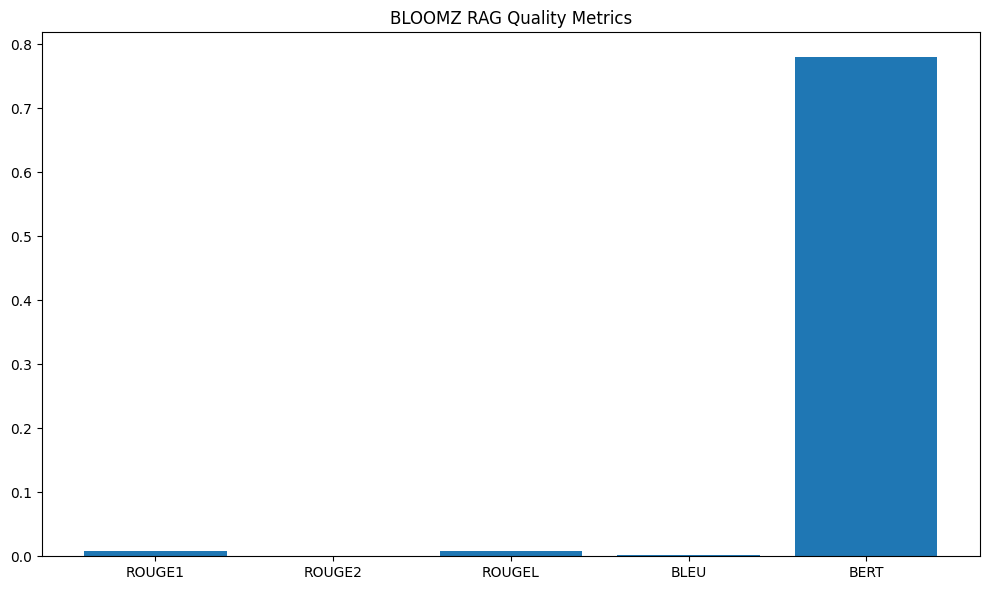

In [ ]:
# ==========================================
# QUALITY PLOT
# ==========================================
plt.figure(figsize=(10,6))

quality_names = ["ROUGE1","ROUGE2","ROUGEL","BLEU","BERT"]
quality_vals = [
    summary_metrics["rouge1"],
    summary_metrics["rouge2"],
    summary_metrics["rougeL"],
    summary_metrics["bleu"]/100,
    summary_metrics["bertscore"]
]

plt.bar(quality_names, quality_vals)
plt.title("BLOOMZ RAG Quality Metrics")
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/quality_metrics.png")
plt.show()

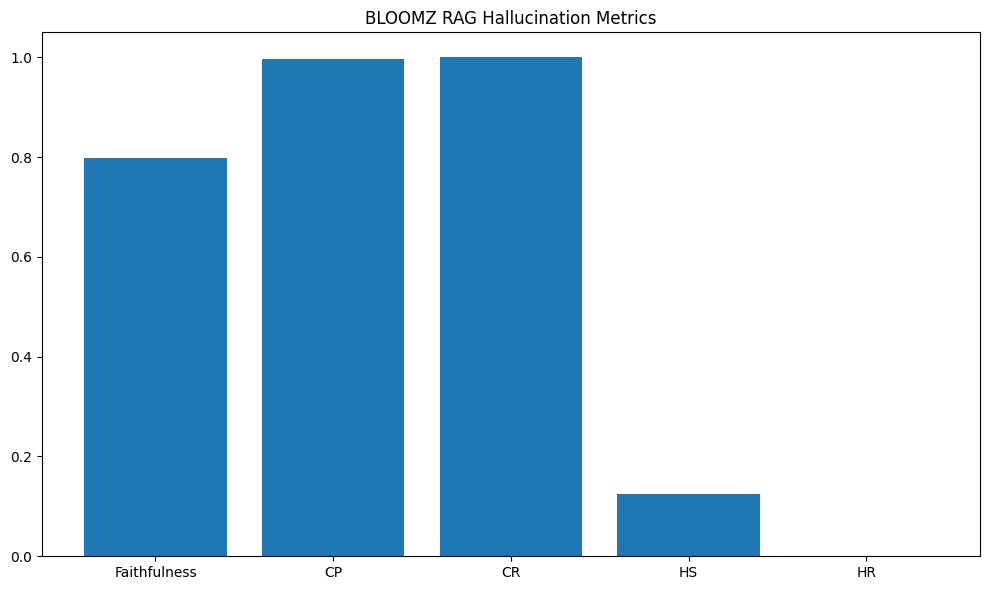

In [ ]:
# ==========================================
# HALLUCINATION PLOT
# ==========================================
plt.figure(figsize=(10,6))

hall_names = ["Faithfulness","CP","CR","HS","HR"]
hall_vals = [
    summary_metrics["faithfulness"],
    summary_metrics["context_precision"],
    summary_metrics["context_recall"],
    summary_metrics["hallucination_score"],
    summary_metrics["hallucination_rate"]
]

plt.bar(hall_names, hall_vals)
plt.title("BLOOMZ RAG Hallucination Metrics")
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/hallucination_metrics.png")
plt.show()

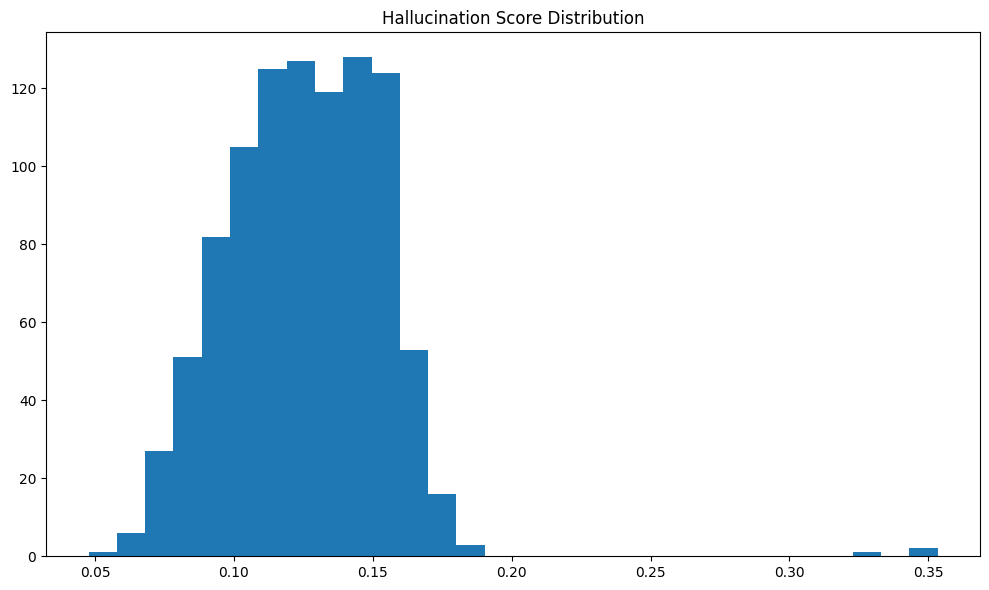

In [ ]:
# ==========================================
# DISTRIBUTION
# ==========================================
plt.figure(figsize=(10,6))
plt.hist(hallucination_scores, bins=30)
plt.title("Hallucination Score Distribution")
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/hallucination_distribution.png")
plt.show()

In [ ]:
# ==========================================
# CLEANUP
# ==========================================
del model
del tokenizer
gc.collect()
torch.cuda.empty_cache()